# Prophet - Walmart Weekly Sales

Per-series Prophet models, built with reusable preprocessor/model classes
(`WalmartHolidayCalendar`, `RepresentativeSeriesSelector`,
`ProphetSeriesPreprocessor`, `ProphetForecaster`) rather than the ad-hoc
functions used in the ARIMA/SARIMA notebooks.

**Three trials, to show breadth of approach** (not just chase one score):
1. Custom Walmart holidays (asymmetric pre/post windows), additive seasonality
2. Same holidays, multiplicative seasonality
3. Winning seasonality mode + economic regressors (Temperature, Fuel_Price,
   CPI, Unemployment) as an ablation -- given plain ARIMAX and SARIMA+exog
   both got *worse* with added regressors earlier, this is a genuine test of
   whether that pattern holds for Prophet too, not an assumed win.

**Fixes applied from the ARIMA/SARIMA review**, so these numbers are
trustworthy from the start rather than needing a second pass:
- No reindexing/interpolation before the train/CV split -- Prophet doesn't
  need a regular time index at all, so this leakage risk doesn't even apply
  here, but we still restrict to *complete* series (no gaps) so results are
  directly comparable to a corrected ARIMA/SARIMA run on the same series.
- **Pooled metrics**: all predictions across series get concatenated first,
  then WMAE/MAE/RMSE computed once over the pooled set -- not an average of
  per-series scores (which isn't the same number).
- `cv_wmae_std` is the std of the **3 fold-level pooled scores**, not
  variability across series.
- Same 30 series (10 low/10 medium/10 high volume, all complete) as intended
  for ARIMA/SARIMA -- saved to `tables/representative_series_v1.csv` here so
  those notebooks can load the identical set later.
- Holdout is evaluated exactly **once**, only for the CV-selected winning
  trial -- not for every trial, which would erode its independence.
- `stage="tuning"`, output goes to `prophet_representative_results.csv`, not
  `_final.csv` -- this is representative-series scope, not the full dataset.

**Before running:** Prophet needs `pip install prophet`. The first fit in
this notebook triggers a one-time Stan backend compile (2-5 min, one time
only, totally normal on Apple Silicon) -- there's a dedicated warm-up cell
below so that happens predictably rather than mid-loop.

In [1]:
import ast
import sys
import time
import logging
import warnings
from collections import defaultdict
from contextlib import contextmanager
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)
logging.getLogger("prophet").setLevel(logging.WARNING)

# Make the project root importable when running the notebook from notebooks/
project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import mlflow

# If your package isn't named "src", change the imports below.
from src.walmart_forecasting.data import load_processed_data
from src.walmart_forecasting.paths import TABLES_DIR
from src.walmart_forecasting.validation import chronological_holdout, expanding_window_splits
from src.walmart_forecasting.experiment import (
    HOLIDAY_WEIGHT,
    NON_HOLIDAY_WEIGHT,
    CV_FOLDS,
    CV_VALIDATION_WEEKS,
    FINAL_HOLDOUT_WEEKS,
    DEFAULT_RANDOM_SEED,
    build_common_parameters,
    build_result_row,
    make_run_name,
)
from src.walmart_forecasting.tracking import mlflow_run

np.random.seed(DEFAULT_RANDOM_SEED)
print("Setup complete.")


Setup complete.


## 0a. Prophet warm-up (run this alone, first)

Triggers Prophet's one-time Stan backend compile in isolation, so it doesn't
happen unpredictably in the middle of the real training loop later.


In [2]:
from prophet import Prophet

_warmup_dates = pd.date_range("2020-01-03", periods=20, freq="W-FRI")
_warmup_df = pd.DataFrame({"ds": _warmup_dates, "y": np.random.default_rng(0).normal(1000, 50, 20)})

_warmup_start = time.perf_counter()
Prophet(weekly_seasonality=False, daily_seasonality=False).fit(_warmup_df)
print(f"Warm-up fit complete in {time.perf_counter() - _warmup_start:.1f}s (first-run compile, if any, is included in this).")


Importing plotly failed. Interactive plots will not work.
22:21:24 - cmdstanpy - INFO - Chain [1] start processing
22:21:24 - cmdstanpy - INFO - Chain [1] done processing


Warm-up fit complete in 0.0s (first-run compile, if any, is included in this).


In [3]:
import logging
cmdstanpy_logger = logging.getLogger("cmdstanpy")
cmdstanpy_logger.addHandler(logging.NullHandler())
cmdstanpy_logger.propagate = False
cmdstanpy_logger.setLevel(logging.CRITICAL)

## 0b. Experiment configuration


In [4]:
ARCHITECTURE = "prophet"
STAGE = "tuning"  # representative_series scope isn't a "final" leaderboard scope
FORECAST_STRATEGY = "local_per_series"
EVALUATION_SCOPE = "representative_series"
EXPERIMENT_NAME = "Prophet_Training"  # one MLflow experiment per architecture

N_PER_TIER = 10  # 3 tiers x 10 = 30 series, matched to what ARIMA/SARIMA should also use
RESULTS_FILENAME = "prophet_representative_results.csv"  # not "_final" -- representative scope only


## 1. Load processed data


In [5]:
processed = load_processed_data()
merged_train = processed.train.copy()
merged_train["Date"] = pd.to_datetime(merged_train["Date"])
merged_train = merged_train.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)

print(f"Train rows: {len(merged_train):,}")
merged_train.head()


Train rows: 421,570


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


## 2. `WalmartHolidayCalendar`

Builds Prophet's required holidays dataframe (`holiday`, `ds`,
`lower_window`, `upper_window`) directly from the data's own `IsHoliday`
flags, rather than hardcoding specific calendar dates from memory -- safer,
and automatically correct for whatever date range your data actually covers.

Buckets holiday weeks by month into the four known Walmart competition
holidays (Super Bowl ~Feb, Labor Day ~Sep, Thanksgiving ~Nov, Christmas
~Dec) and gives each an asymmetric window in days, since actual sales spikes
often happen *before* the flagged week (e.g. Christmas shopping peaks before
Dec 25, not during Christmas week itself) -- something ARIMA's single
boolean holiday flag structurally can't express.


In [6]:
class WalmartHolidayCalendar:
    """Builds a Prophet-format holidays dataframe from a dataset's IsHoliday flags."""

    MONTH_TO_HOLIDAY = {
        2: "SuperBowl",
        9: "LaborDay",
        11: "Thanksgiving",
        12: "Christmas",
    }

    # (lower_window, upper_window) in days. Negative = effect starts before the flagged date.
    DEFAULT_WINDOWS = {
        "SuperBowl": (-3, 1),
        "LaborDay": (-3, 1),
        "Thanksgiving": (-3, 1),
        "Christmas": (-10, 2),  # shopping ramps up well before the holiday week itself
    }

    def __init__(self, windows=None):
        self.windows = {**self.DEFAULT_WINDOWS, **(windows or {})}

    def build(self, dataframe, date_col="Date", is_holiday_col="IsHoliday"):
        holiday_dates = (
            dataframe.loc[dataframe[is_holiday_col].astype(bool), date_col]
            .dropna()
            .drop_duplicates()
            .sort_values()
        )

        rows = []
        for date in holiday_dates:
            holiday_name = self.MONTH_TO_HOLIDAY.get(date.month)
            if holiday_name is None:
                continue
            lower, upper = self.windows[holiday_name]
            rows.append({
                "holiday": holiday_name,
                "ds": date,
                "lower_window": lower,
                "upper_window": upper,
            })

        return pd.DataFrame(rows)


## 3. `RepresentativeSeriesSelector`

Restricts to *complete* series (present for every week in the data's date
range -- no gaps) and stratifies a sample by sales-volume tercile. This is
the same 30-series set intended for the corrected ARIMA/SARIMA notebooks --
saved to `tables/representative_series_v1.csv` here so this notebook is the
source of truth and the others can load it directly instead of re-deriving
it (and risking a different sample).


In [7]:
class RepresentativeSeriesSelector:
    """Selects a stratified sample of complete (no-gap) series, saved for reuse across notebooks."""

    def __init__(self, n_per_tier=10, random_seed=DEFAULT_RANDOM_SEED):
        self.n_per_tier = n_per_tier
        self.random_seed = random_seed

    def _complete_series(self, dataframe, date_col="Date"):
        global_min = dataframe[date_col].min()
        global_max = dataframe[date_col].max()
        total_weeks = dataframe[date_col].nunique()

        summary = (
            dataframe.groupby(["Store", "Dept"])
            .agg(
                first_date=(date_col, "min"),
                last_date=(date_col, "max"),
                n_weeks=(date_col, "nunique"),
                total_sales=("Weekly_Sales", "sum"),
            )
            .reset_index()
        )

        return summary[
            (summary["first_date"] == global_min)
            & (summary["last_date"] == global_max)
            & (summary["n_weeks"] == total_weeks)
        ].copy()

    def select(self, dataframe, date_col="Date"):
        complete = self._complete_series(dataframe, date_col=date_col)
        complete["volume_tier"] = pd.qcut(complete["total_sales"], q=3, labels=["low", "medium", "high"])

        parts = []
        for tier in complete["volume_tier"].cat.categories:
            tier_df = complete[complete["volume_tier"] == tier]
            n = min(self.n_per_tier, len(tier_df))
            parts.append(tier_df.sample(n=n, random_state=self.random_seed))

        selected = pd.concat(parts).reset_index(drop=True)
        return selected, list(zip(selected["Store"], selected["Dept"]))

    def select_and_save(self, dataframe, path, date_col="Date"):
        selected, keys = self.select(dataframe, date_col=date_col)
        selected.to_csv(path, index=False)
        return selected, keys

    @staticmethod
    def load(path):
        selected = pd.read_csv(path)
        return selected, list(zip(selected["Store"], selected["Dept"]))


In [8]:
selector = RepresentativeSeriesSelector(n_per_tier=N_PER_TIER)

series_path = TABLES_DIR / "representative_series_v1.csv"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

selected, selected_keys = selector.select_and_save(merged_train, series_path)
print(f"Selected {len(selected_keys)} complete series across volume tiers, saved to {series_path.name}")
selected[["Store", "Dept", "total_sales", "n_weeks", "volume_tier"]]


Selected 30 complete series across volume tiers, saved to representative_series_v1.csv


,Store,Dept,total_sales,n_weeks,volume_tier
0,15,52,223257.76,143,low
1,35,83,357099.15,143,low
2,28,52,378310.35,143,low
3,33,74,51952.16,143,low
4,32,52,359356.63,143,low
5,3,21,177967.74,143,low
6,28,31,369504.14,143,low
7,30,98,458605.96,143,low
8,37,87,145869.61,143,low
9,7,31,257336.97,143,low


## 4. `ProphetSeriesPreprocessor`

Builds the Prophet-ready `(ds, y, [regressors])` dataframe for one series --
**no reindexing, no interpolation**, just the weeks that series actually
has, renamed to Prophet's expected column names. Any gaps in regressor
columns (Temperature/Fuel_Price/CPI/Unemployment occasionally have a few
missing values even on observed sales weeks) get median-filled, since
Prophet can't take NaN in a regressor column.


In [9]:
class ProphetSeriesPreprocessor:
    """Builds a Prophet-ready dataframe for one Store-Dept series. No interpolation of the target."""

    def __init__(self, regressor_cols=None):
        self.regressor_cols = list(regressor_cols or [])

    def build(self, dataframe, store, dept, date_col="Date", value_col="Weekly_Sales"):
        series = (
            dataframe[(dataframe["Store"] == store) & (dataframe["Dept"] == dept)]
            .sort_values(date_col)
            .copy()
        )

        result = pd.DataFrame({
            "ds": series[date_col].values,
            "y": series[value_col].values,
            "IsHoliday": series["IsHoliday"].astype(bool).values,
        })

        for col in self.regressor_cols:
            values = series[col].astype(float)
            if values.isna().any():
                values = values.fillna(values.median())
            result[col] = values.values

        return result


## 5. `ProphetForecaster`

Wraps a single-series Prophet model: holidays, seasonality mode, optional
regressors. Weekly and daily seasonality are disabled -- there's only one
observation per week in this data, so there's nothing for Prophet to learn
at those granularities; only yearly seasonality makes sense here.


In [10]:
import os


@contextmanager
def suppress_stdout_stderr():
    """Prophet/cmdstanpy print a lot per fit -- this keeps ~300+ fits from flooding the notebook."""
    with open(os.devnull, "w") as devnull:
        old_stdout, old_stderr = sys.stdout, sys.stderr
        sys.stdout, sys.stderr = devnull, devnull
        try:
            yield
        finally:
            sys.stdout, sys.stderr = old_stdout, old_stderr


class ProphetForecaster:
    """Fits/predicts a single Prophet model for one series."""

    def __init__(self, holidays=None, seasonality_mode="additive", regressor_cols=None):
        self.holidays = holidays
        self.seasonality_mode = seasonality_mode
        self.regressor_cols = list(regressor_cols or [])
        self.model = None

    def fit(self, train_df):
        self.model = Prophet(
            holidays=self.holidays,
            seasonality_mode=self.seasonality_mode,
            weekly_seasonality=False,
            daily_seasonality=False,
            yearly_seasonality=True,
        )
        for col in self.regressor_cols:
            self.model.add_regressor(col)

        with suppress_stdout_stderr():
            self.model.fit(train_df[["ds", "y", *self.regressor_cols]])

        return self

    def predict(self, future_df):
        columns = ["ds", *self.regressor_cols]
        with suppress_stdout_stderr():
            forecast = self.model.predict(future_df[columns])
        return forecast["yhat"].values


## 6. Weighted MAE (pooled)


In [11]:
def weighted_mae(y_true, y_pred, is_holiday):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weights = np.where(np.asarray(is_holiday, dtype=bool), HOLIDAY_WEIGHT, NON_HOLIDAY_WEIGHT)
    return float(np.average(np.abs(y_true - y_pred), weights=weights))


## 7. Build the holidays dataframe


In [12]:
holiday_calendar = WalmartHolidayCalendar()
walmart_holidays = holiday_calendar.build(merged_train)
print(f"{len(walmart_holidays)} holiday occurrences across {walmart_holidays['holiday'].nunique()} named holidays")
walmart_holidays.groupby("holiday").size()


10 holiday occurrences across 4 named holidays


holiday
Christmas       2
LaborDay        3
SuperBowl       3
Thanksgiving    2
dtype: int64

## 8. Trial runner

Pools predictions across series **per fold** (so `cv_wmae_mean`/`std` are
true pooled scores, not an average of per-series numbers), and only touches
holdout when explicitly asked (`do_holdout=True`) -- keeps it untouched
during trial comparison, and lets the final winning run skip redundant CV
refitting via `do_cv=False`.


In [13]:
def run_prophet_trial(selected_keys, seasonality_mode, regressor_cols, holidays_df, label, do_cv=True, do_holdout=False):
    preprocessor = ProphetSeriesPreprocessor(regressor_cols=regressor_cols)

    fold_prediction_rows = defaultdict(list)
    holdout_prediction_rows = []
    total_fit_seconds = 0.0
    total_predict_seconds = 0.0

    for store, dept in selected_keys:
        series_df = preprocessor.build(merged_train, store, dept)

        try:
            holdout_split = chronological_holdout(series_df, validation_weeks=FINAL_HOLDOUT_WEEKS, date_column="ds")
            if do_cv:
                cv_splits = expanding_window_splits(
                    holdout_split.train, n_splits=CV_FOLDS, validation_weeks=CV_VALIDATION_WEEKS, date_column="ds"
                )
        except ValueError:
            continue

        if do_cv:
            for fold_index, fold in enumerate(cv_splits):
                forecaster = ProphetForecaster(holidays=holidays_df, seasonality_mode=seasonality_mode, regressor_cols=regressor_cols)

                fit_start = time.perf_counter()
                forecaster.fit(fold.train)
                total_fit_seconds += time.perf_counter() - fit_start

                predict_start = time.perf_counter()
                yhat = forecaster.predict(fold.validation)
                total_predict_seconds += time.perf_counter() - predict_start

                fold_prediction_rows[fold_index].append(pd.DataFrame({
                    "Store": store, "Dept": dept, "ds": fold.validation["ds"].values,
                    "actual": fold.validation["y"].values, "prediction": yhat,
                    "IsHoliday": fold.validation["IsHoliday"].values,
                }))

        if do_holdout:
            forecaster = ProphetForecaster(holidays=holidays_df, seasonality_mode=seasonality_mode, regressor_cols=regressor_cols)

            fit_start = time.perf_counter()
            forecaster.fit(holdout_split.train)
            total_fit_seconds += time.perf_counter() - fit_start

            predict_start = time.perf_counter()
            yhat = forecaster.predict(holdout_split.validation)
            total_predict_seconds += time.perf_counter() - predict_start

            holdout_prediction_rows.append(pd.DataFrame({
                "Store": store, "Dept": dept, "ds": holdout_split.validation["ds"].values,
                "actual": holdout_split.validation["y"].values, "prediction": yhat,
                "IsHoliday": holdout_split.validation["IsHoliday"].values,
            }))

    result = {
        "label": label,
        "seasonality_mode": seasonality_mode,
        "regressor_cols": regressor_cols,
        "fit_seconds": total_fit_seconds,
        "predict_seconds": total_predict_seconds,
        "series_count": len(selected_keys),
    }

    if do_cv:
        fold_wmaes = []
        for fold_index in sorted(fold_prediction_rows):
            pooled = pd.concat(fold_prediction_rows[fold_index], ignore_index=True)
            fold_wmaes.append(weighted_mae(pooled["actual"], pooled["prediction"], pooled["IsHoliday"]))
        result["cv_wmae_mean"] = float(np.mean(fold_wmaes))
        result["cv_wmae_std"] = float(np.std(fold_wmaes))
        result["fold_wmaes"] = fold_wmaes

    if do_holdout and holdout_prediction_rows:
        pooled_holdout = pd.concat(holdout_prediction_rows, ignore_index=True)
        result["holdout_wmae"] = weighted_mae(pooled_holdout["actual"], pooled_holdout["prediction"], pooled_holdout["IsHoliday"])
        result["holdout_mae"] = float(np.mean(np.abs(pooled_holdout["actual"] - pooled_holdout["prediction"])))
        result["holdout_rmse"] = float(np.sqrt(np.mean((pooled_holdout["actual"] - pooled_holdout["prediction"]) ** 2)))
        result["pooled_holdout_predictions"] = pooled_holdout

    summary_bits = []
    if do_cv:
        summary_bits.append(f"cv_wmae_mean={result['cv_wmae_mean']:,.1f}")
    if do_holdout:
        summary_bits.append(f"holdout_wmae={result['holdout_wmae']:,.1f}")
    print(f"[{label}] " + ", ".join(summary_bits) + f", fit={total_fit_seconds:.1f}s")

    return result


## 9. Trial A vs Trial B: seasonality mode

Same holidays, same series, same everything else -- only `seasonality_mode`
differs. CV only, holdout untouched.


In [14]:
trial_a = run_prophet_trial(
    selected_keys, seasonality_mode="additive", regressor_cols=[],
    holidays_df=walmart_holidays, label="A_additive_holidays_only",
)


[A_additive_holidays_only] cv_wmae_mean=1,770.9, fit=19.5s


In [15]:
trial_b = run_prophet_trial(
    selected_keys, seasonality_mode="multiplicative", regressor_cols=[],
    holidays_df=walmart_holidays, label="B_multiplicative_holidays_only",
)


[B_multiplicative_holidays_only] cv_wmae_mean=1,678.4, fit=18.7s


## 10. Trial C: economic regressors ablation

Uses whichever seasonality mode won A vs B, adds `Temperature`, `Fuel_Price`,
`CPI`, `Unemployment` as Prophet regressors. Given plain ARIMAX and
SARIMA+`IsHoliday` both got *worse* with added regressors on short series,
this is a real test of whether that pattern holds here too -- not an assumed
win for "more features."


In [16]:
winning_mode_ab = trial_a["seasonality_mode"] if trial_a["cv_wmae_mean"] <= trial_b["cv_wmae_mean"] else trial_b["seasonality_mode"]
print(f"A vs B winner by CV WMAE: {winning_mode_ab}")

ECONOMIC_REGRESSORS = ["Temperature", "Fuel_Price", "CPI", "Unemployment"]

trial_c = run_prophet_trial(
    selected_keys, seasonality_mode=winning_mode_ab, regressor_cols=ECONOMIC_REGRESSORS,
    holidays_df=walmart_holidays, label="C_regressors_ablation",
)


A vs B winner by CV WMAE: multiplicative
[C_regressors_ablation] cv_wmae_mean=5,275.6, fit=17.5s


## 11. Compare all three trials, pick the winner by CV WMAE


In [17]:
trials = [trial_a, trial_b, trial_c]

comparison = pd.DataFrame([
    {"trial": t["label"], "seasonality_mode": t["seasonality_mode"],
     "regressors": t["regressor_cols"], "cv_wmae_mean": t["cv_wmae_mean"], "cv_wmae_std": t["cv_wmae_std"]}
    for t in trials
])
comparison.sort_values("cv_wmae_mean")


,trial,seasonality_mode,regressors,cv_wmae_mean,cv_wmae_std
1,B_multiplicative_holidays_only,multiplicative,[],1678.420480,150.850958
0,A_additive_holidays_only,additive,[],1770.922755,193.886134
2,C_regressors_ablation,multiplicative,"[Temperature, Fuel_Price, CPI, Unemployment]",5275.599769,3996.363956


In [18]:
winner = min(trials, key=lambda t: t["cv_wmae_mean"])
print(f"Winner by CV WMAE: {winner['label']} (cv_wmae_mean={winner['cv_wmae_mean']:,.1f})")

FEATURE_SET = (
    "prophet_calendar_economic_v1" if winner["regressor_cols"] else "target_holiday_windows_v1"
)
PREPROCESSING = "prophet_native_no_interpolation_v1"
TRIAL_NAME = winner["label"].lower()


Winner by CV WMAE: B_multiplicative_holidays_only (cv_wmae_mean=1,678.4)


## 12. Final holdout -- evaluated exactly once, only for the winner

`do_cv=False` here since we already have the winner's CV numbers from
section 9/10 -- no need to refit those folds again. This is also wrapped in
the MLflow run context *before* fitting starts, so the logged run duration
on DagsHub reflects real training time, not just the final logging calls.


In [19]:
run_name = make_run_name(
    architecture=ARCHITECTURE,
    stage=STAGE,
    feature_set=FEATURE_SET,
    trial_name=TRIAL_NAME,
)

common_params = build_common_parameters(
    architecture=ARCHITECTURE,
    stage=STAGE,
    feature_set=FEATURE_SET,
    preprocessing=PREPROCESSING,
    evaluation_scope=EVALUATION_SCOPE,
    forecast_strategy=FORECAST_STRATEGY,
    series_count=len(selected_keys),
    random_seed=DEFAULT_RANDOM_SEED,
    extra_parameters={
        "seasonality_mode": winner["seasonality_mode"],
        "regressor_cols": winner["regressor_cols"],
        "holiday_names": sorted(walmart_holidays["holiday"].unique().tolist()),
        "trials_compared": [t["label"] for t in trials],
    },
)

TABLES_DIR.mkdir(parents=True, exist_ok=True)
results_path = TABLES_DIR / RESULTS_FILENAME

with mlflow_run(
    experiment_name=EXPERIMENT_NAME,
    run_name=run_name,
    parameters=common_params,
    tags={"architecture": ARCHITECTURE, "stage": STAGE, "scope": EVALUATION_SCOPE, "trial": TRIAL_NAME},
) as run:

    holdout_only = run_prophet_trial(
        selected_keys, seasonality_mode=winner["seasonality_mode"], regressor_cols=winner["regressor_cols"],
        holidays_df=walmart_holidays, label=winner["label"] + "_final_holdout", do_cv=False, do_holdout=True,
    )

    final_metrics = {
        "cv_wmae_mean": winner["cv_wmae_mean"],
        "cv_wmae_std": winner["cv_wmae_std"],
        "holdout_wmae": holdout_only["holdout_wmae"],
        "holdout_mae": holdout_only["holdout_mae"],
        "holdout_rmse": holdout_only["holdout_rmse"],
    }

    total_fit_seconds = winner["fit_seconds"] + holdout_only["fit_seconds"]
    total_predict_seconds = winner["predict_seconds"] + holdout_only["predict_seconds"]

    mlflow.log_metrics({**final_metrics, "fit_seconds": total_fit_seconds, "predict_seconds": total_predict_seconds})

    holdout_only["pooled_holdout_predictions"].to_csv(TABLES_DIR / "prophet_holdout_predictions.csv", index=False)
    mlflow.log_artifact(str(TABLES_DIR / "prophet_holdout_predictions.csv"))

print("\nFinal metrics (winner, evaluated once on holdout):")
for key, value in final_metrics.items():
    print(f"  {key}: {value:,.2f}")


Accessing as lchkh23

Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

2026/07/08 22:23:32 INFO mlflow.tracking.fluent: Experiment with name 'Prophet_Training' does not exist. Creating a new experiment.


[B_multiplicative_holidays_only_final_holdout] holdout_wmae=1,789.1, fit=0.6s
🏃 View run prophet__tuning__target_holiday_windows_v1__b_multiplicative_holidays_only__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/5/runs/ae5894bcb8454e6ab593b89f1be3530d
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/5

Final metrics (winner, evaluated once on holdout):
  cv_wmae_mean: 1,678.42
  cv_wmae_std: 150.85
  holdout_wmae: 1,789.11
  holdout_mae: 1,749.90
  holdout_rmse: 3,672.91


## 13. Save to the shared representative-results CSV

Also logs the two non-winning trials to MLflow separately (CV-only, no
holdout metrics -- they never touched holdout), so all three are visible
side by side on DagsHub even though only the winner got the full run.


In [20]:
result_row = build_result_row(
    architecture=ARCHITECTURE,
    run_name=run_name,
    stage=STAGE,
    tracker="mlflow",
    feature_set=FEATURE_SET,
    preprocessing=PREPROCESSING,
    evaluation_scope=EVALUATION_SCOPE,
    forecast_strategy=FORECAST_STRATEGY,
    series_count=len(selected_keys),
    metrics=final_metrics,
    fit_seconds=total_fit_seconds,
    predict_seconds=total_predict_seconds,
    notes=(
        f"Prophet, winning config from 3 trials (additive/multiplicative seasonality, "
        f"economic-regressor ablation): {winner['label']}. Holdout evaluated once, only "
        f"for this winning trial. Representative series, not full dataset."
    ),
)

results_row_df = pd.DataFrame([result_row])
if results_path.exists():
    existing = pd.read_csv(results_path)
    results_row_df = pd.concat([existing, results_row_df], ignore_index=True)
results_row_df.to_csv(results_path, index=False)
print(f"Saved winning result to {results_path.name}")


def feature_set_for(trial):
    return "prophet_calendar_economic_v1" if trial["regressor_cols"] else "target_holiday_windows_v1"


for trial in trials:
    if trial["label"] == winner["label"]:
        continue  # already logged above with the full run

    trial_feature_set = feature_set_for(trial)
    trial_run_name = make_run_name(architecture=ARCHITECTURE, stage=STAGE, feature_set=trial_feature_set, trial_name=trial["label"].lower())
    trial_params = build_common_parameters(
        architecture=ARCHITECTURE, stage=STAGE, feature_set=trial_feature_set, preprocessing=PREPROCESSING,
        evaluation_scope=EVALUATION_SCOPE, forecast_strategy=FORECAST_STRATEGY, series_count=len(selected_keys),
        extra_parameters={"seasonality_mode": trial["seasonality_mode"], "regressor_cols": trial["regressor_cols"]},
    )
    with mlflow_run(
        experiment_name=EXPERIMENT_NAME, run_name=trial_run_name, parameters=trial_params,
        tags={"architecture": ARCHITECTURE, "stage": STAGE, "trial": trial["label"].lower()},
    ):
        mlflow.log_metrics({
            "cv_wmae_mean": trial["cv_wmae_mean"], "cv_wmae_std": trial["cv_wmae_std"],
            "fit_seconds": trial["fit_seconds"], "predict_seconds": trial["predict_seconds"],
        })

print("Logged non-winning trials to MLflow (CV-only, no holdout).")


Saved winning result to prophet_representative_results.csv


Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

🏃 View run prophet__tuning__target_holiday_windows_v1__a_additive_holidays_only__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/5/runs/c5fd17289cba4f3cb431836764b7deb7
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/5


Initialized MLflow to track repo "lkhiz23/walmart-store-sales-forecasting"

Repository lkhiz23/walmart-store-sales-forecasting initialized!

🏃 View run prophet__tuning__prophet_calendar_economic_v1__c_regressors_ablation__s42 at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/5/runs/275e4ed5ea3f4f7ea3ad1d38a120d178
🧪 View experiment at: https://dagshub.com/lkhiz23/walmart-store-sales-forecasting.mlflow/#/experiments/5
Logged non-winning trials to MLflow (CV-only, no holdout).


## 14. A few forecasts, visually


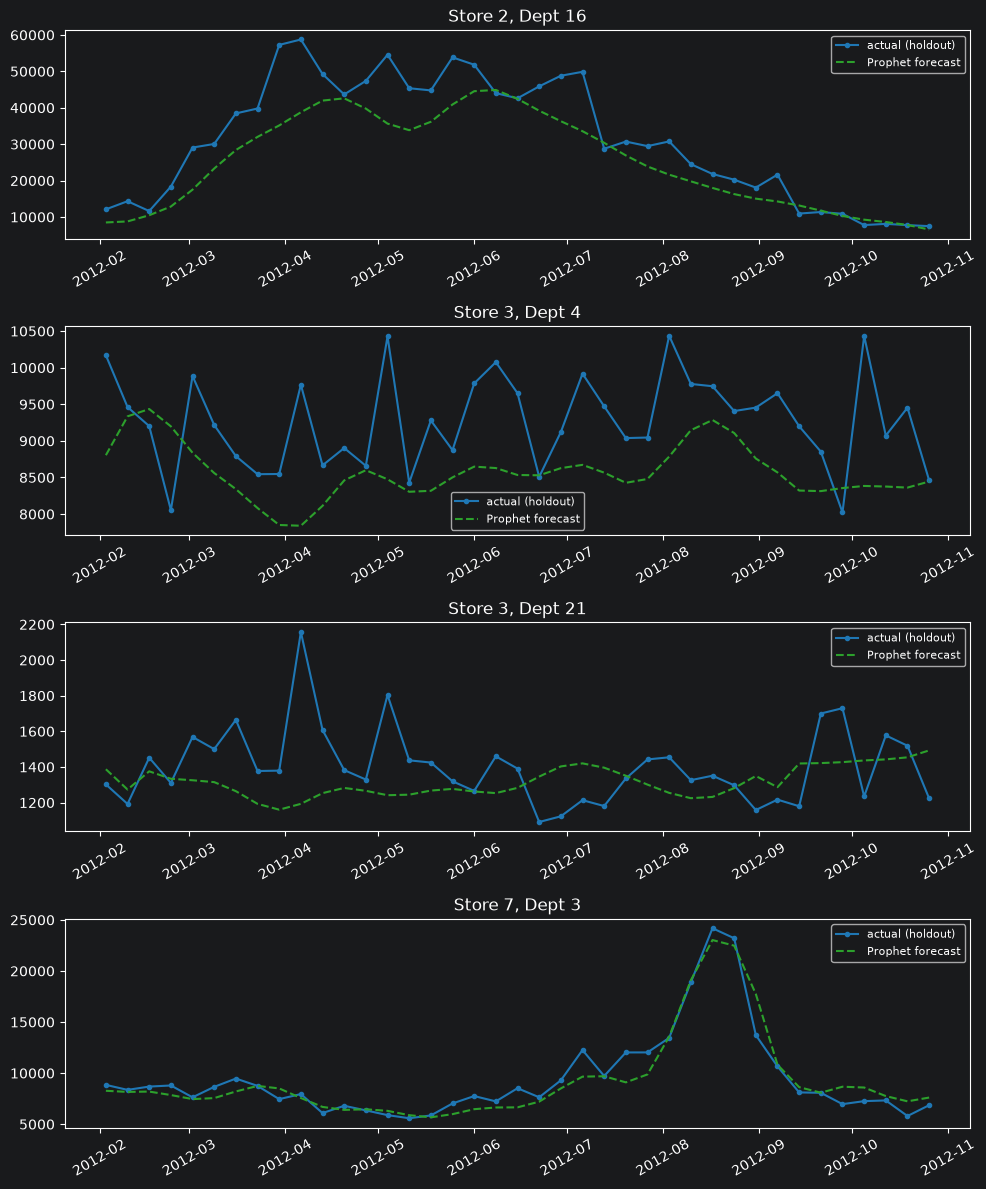

In [21]:
sample_series = holdout_only["pooled_holdout_predictions"].groupby(["Store", "Dept"])
sample_keys = list(sample_series.groups.keys())[:4]

fig, axes = plt.subplots(len(sample_keys), 1, figsize=(10, 3 * len(sample_keys)))
if len(sample_keys) == 1:
    axes = [axes]

for ax, key in zip(axes, sample_keys):
    subset = sample_series.get_group(key).sort_values("ds")
    ax.plot(subset["ds"], subset["actual"], label="actual (holdout)", color="tab:blue", marker="o", markersize=3)
    ax.plot(subset["ds"], subset["prediction"], label="Prophet forecast", color="tab:green", linestyle="--")
    ax.set_title(f"Store {key[0]}, Dept {key[1]}")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


## 15. Takeaways & next steps

- Three genuinely different approaches were compared on **identical series**
  with **pooled metrics**, and holdout was only spent once, on the actual
  winner -- these numbers should hold up under scrutiny better than the
  earlier ARIMA/SARIMA numbers did.
- Check `comparison` (section 11): if Trial C (regressors) lost to A/B, that
  continues the pattern from ARIMAX and SARIMA+exog -- exogenous regressors
  on short per-series windows seem to consistently add instability rather
  than signal for this dataset. If it *won* here, that's worth noting as a
  genuine difference in how Prophet handles regressors vs ARIMA's exog
  (Prophet regressors get their own smooth trend contribution, rather than
  being folded into the AR/MA structure directly).
- `tables/representative_series_v1.csv` now exists -- reuse it directly in
  the corrected ARIMA/SARIMA notebooks (`RepresentativeSeriesSelector.load(path)`)
  so all three statistical approaches are finally compared on the same 30
  series, which they weren't before.
- Next natural comparison: Seasonal Naive (the actual `stage="baseline"`
  reference your protocol calls for) on this same series set, so you have a
  real floor to compare ARIMA/SARIMA/Prophet against, not just each other.
